In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.feature_selection import (
    mutual_info_classif,
    SelectKBest
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [2]:
df=pd.read_csv("Telco-Customer-Churn-dataset.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.drop("customerID", axis=1, inplace=True)

In [4]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [8]:
# ===== FEATURE ENGINEERING =====
df["AvgMonthlySpend"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

df["IsLongTermCustomer"] = (
    df["tenure"] > 24
).astype(int)

In [9]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_cols:
    df[col] = df[col].replace({
        "Yes": 1,
        "No": 0,
        "No internet service": 0
    })

df["ServiceCount"] = df[service_cols].sum(axis=1)


In [10]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
df.head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsLongTermCustomer,gender_Male,Partner_Yes,Dependents_Yes,...,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ServiceCount_1,ServiceCount_2,ServiceCount_3,ServiceCount_4,ServiceCount_5,ServiceCount_6
0,0,1,29.85,29.85,0,14.925000,0,False,True,False,...,True,False,True,False,True,False,False,False,False,False
1,0,34,56.95,1889.50,0,53.985714,1,True,False,False,...,False,False,False,True,False,True,False,False,False,False
2,0,2,53.85,108.15,1,36.050000,0,True,False,False,...,True,False,False,True,False,True,False,False,False,False
3,0,45,42.30,1840.75,0,40.016304,1,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,0,2,70.70,151.65,1,50.550000,0,False,False,False,...,True,False,True,False,False,False,False,False,False,False
5,0,8,99.65,820.50,1,91.166667,0,False,False,False,...,True,False,True,False,False,False,True,False,False,False
6,0,22,89.10,1949.40,0,84.756522,0,True,False,True,...,True,True,False,False,False,True,False,False,False,False
7,0,10,29.75,301.90,0,27.445455,0,False,False,False,...,False,False,False,True,True,False,False,False,False,False
8,0,28,104.80,3046.05,1,105.036207,1,False,True,False,...,True,False,True,False,False,False,False,True,False,False
9,0,62,56.15,3487.95,0,55.364286,1,True,False,True,...,False,False,False,False,False,True,False,False,False,False


In [12]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [15]:
print(df[["TotalCharges", "AvgMonthlySpend"]].isnull().sum())

TotalCharges       0
AvgMonthlySpend    0
dtype: int64


In [16]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

model = SVC(kernel='rbf',class_weight='balanced')  # default kernel

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1')

print("CV F1:", scores)
model.fit(X_train, y_train)

CV F1: [0.45034965 0.47075606 0.48183042 0.47659574 0.50997151]


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6799148332150461
              precision    recall  f1-score   support

           0       0.83      0.71      0.76      1036
           1       0.43      0.61      0.50       373

    accuracy                           0.68      1409
   macro avg       0.63      0.66      0.63      1409
weighted avg       0.73      0.68      0.69      1409



In [18]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   AvgMonthlySpend                        7043 non-null   float64
 6   IsLongTermCustomer                     7043 non-null   int64  
 7   gender_Male                            7043 non-null   int64  
 8   Partner_Yes                            7043 non-null   int64  
 9   Dependents_Yes                         7043 non-null   int64  
 10  PhoneService_Yes                       7043 non-null   int64  
 11  MultipleLines_N

In [20]:
corr = df.corr()

churn_corr = corr["Churn"].sort_values(ascending=False)
print(churn_corr)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
ServiceCount_1                           0.173543
SeniorCitizen                            0.150889
ServiceCount_2                           0.087146
StreamingTV_1                            0.063228
StreamingMovies_1                        0.061382
MultipleLines_Yes                        0.040102
AvgMonthlySpend                          0.014873
PhoneService_Yes                         0.011942
ServiceCount_3                           0.008198
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
ServiceCount_4                          -0.035595
DeviceProtection_1                      -0.066160
OnlineBackup_1                          -0.082255
PaymentMethod_Mailed check              -0.091683


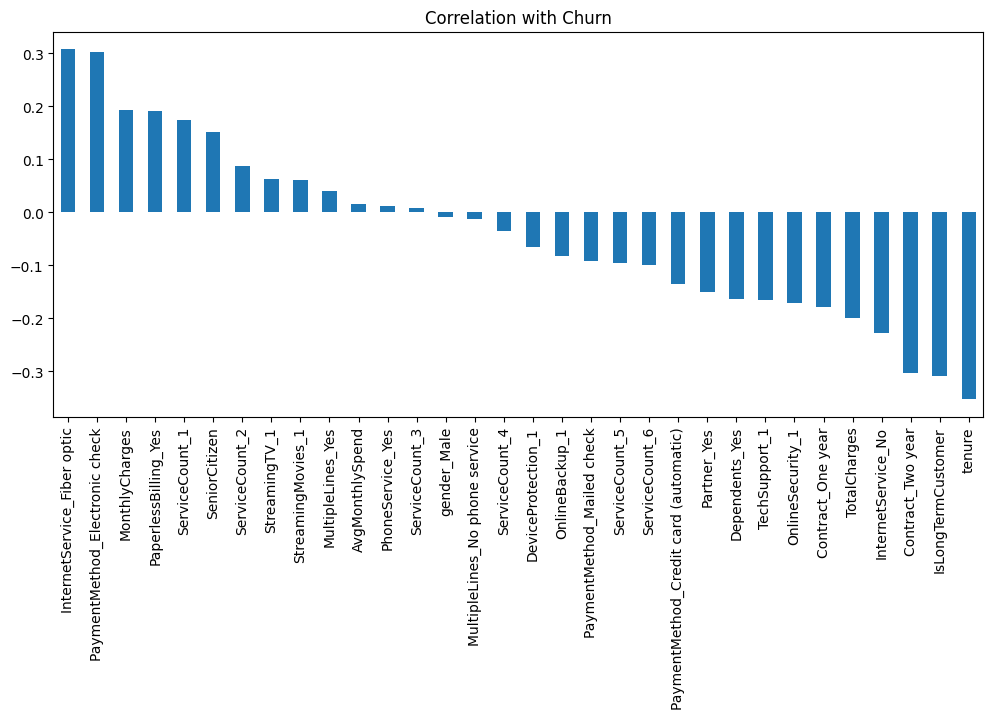

In [21]:
import matplotlib.pyplot as plt

churn_corr.drop("Churn").plot(kind='bar', figsize=(12,5))
plt.title("Correlation with Churn")
plt.show()

# Correlation analysis select most important features and then train svm


In [24]:
top_features = [
    "tenure",
    "Contract_Two year",
    "Contract_One year",
    "InternetService_Fiber optic",
    "MonthlyCharges",
    "PaymentMethod_Electronic check",
    "OnlineSecurity_1",
    "TechSupport_1"
]

In [25]:
X_selected = X[top_features]

In [26]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [27]:
model = SVC(kernel='rbf',class_weight='balanced')  # default kernel
model.fit(X_train_2, y_train_2)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
y_pred = model.predict(X_test_2)

print("Accuracy:", accuracy_score(y_test_2, y_pred))
print(classification_report(y_test_2, y_pred))

Accuracy: 0.7317246273953159
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1036
           1       0.50      0.80      0.61       373

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



## Using mutual relationship and decision tree for feature selection

In [29]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsLongTermCustomer,gender_Male,Partner_Yes,Dependents_Yes,...,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ServiceCount_1,ServiceCount_2,ServiceCount_3,ServiceCount_4,ServiceCount_5,ServiceCount_6
0,0,1,29.85,29.85,0,14.925000,0,0,1,0,...,1,0,1,0,1,0,0,0,0,0
1,0,34,56.95,1889.50,0,53.985714,1,1,0,0,...,0,0,0,1,0,1,0,0,0,0
2,0,2,53.85,108.15,1,36.050000,0,1,0,0,...,1,0,0,1,0,1,0,0,0,0
3,0,45,42.30,1840.75,0,40.016304,1,1,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,2,70.70,151.65,1,50.550000,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0


In [30]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
pipeline = Pipeline([
    ("feature_selection", SelectKBest(mutual_info_classif, k=10)),
    ("scaler", StandardScaler()),
    ("svm", SVC(class_weight='balanced'))
])

In [31]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_selection', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function mut...t 0x1200ec040>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'


In [32]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_selection', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function mut...t 0x1200ec040>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'


In [33]:
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7473385379701917
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.51      0.84      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.75      0.76      1409



# used gridsearch for hyperparamter tuning of svm

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "feature_selection__k": [5, 10, 15, 20],
    "svm__C": [0.1, 1, 10, 50],
    "svm__gamma": ["scale", 0.01, 0.1, 1]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1'   # IMPORTANT for imbalance
)

grid.fit(X_train, y_train)

print(grid.best_params_)
{'feature_selection__k': 15, 'svm__C': 0.1, 'svm__gamma': 1}

{'feature_selection__k': 15, 'svm__C': 0.1, 'svm__gamma': 0.1}


{'feature_selection__k': 15, 'svm__C': 0.1, 'svm__gamma': 1}

In [35]:
# Build pipeline with best params
best_pipeline = Pipeline([
    ("feature_selection", SelectKBest(mutual_info_classif, k=15)),
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel='rbf', C=0.1, gamma=1, class_weight='balanced'))
])
# Train
best_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_selection', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function mut...t 0x1200ec040>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",15
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'


In [36]:
y_pred = best_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8062455642299503
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1036
           1       0.65      0.58      0.61       373

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



# using Logistic regression model without feature selection as baseline model

In [37]:
from sklearn.linear_model import LogisticRegression
input=[("scaler",StandardScaler()),("model",LogisticRegression(class_weight='balanced', max_iter=1000))]
pipeline_lr=Pipeline(input)
pipeline_lr.fit(X_train ,y_train)
y_pred=pipeline_lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7665010645848119
              precision    recall  f1-score   support

           0       0.92      0.75      0.82      1036
           1       0.54      0.82      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



In [38]:
from sklearn.linear_model import LogisticRegression
input=[("scaler",StandardScaler()),("model",LogisticRegression(penalty='l1',
        solver='liblinear',   # REQUIRED for L1
        class_weight='balanced',
        max_iter=1000))]
pipeline_l1=Pipeline(input)
pipeline_l1.fit(X_train ,y_train)
y_pred=pipeline_l1.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

/Users/disha/Downloads/labllerr_assignment/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/disha/Downloads/labllerr_assignment/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Accuracy: 0.7665010645848119
              precision    recall  f1-score   support

           0       0.92      0.75      0.82      1036
           1       0.54      0.82      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



In [39]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

pipeline_lr_fs = Pipeline([
    ("feature_selection", SelectKBest(mutual_info_classif, k=10)),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(class_weight='balanced', max_iter=1000))
])

pipeline_lr_fs.fit(X_train, y_train)

y_pred = pipeline_lr_fs.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7487579843860894
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.82      0.63       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



In [40]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [41]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [42]:
scores = cross_val_score(pipeline_lr, X_train, y_train, cv=kfold, scoring='accuracy')

print("K-Fold Accuracies:", scores)
print("Mean Accuracy:", scores.mean())

K-Fold Accuracies: [0.73114463 0.74534161 0.75776398 0.74800355 0.76909414]
Mean Accuracy: 0.7502695819234327


In [43]:
scores_l1 = cross_val_score(pipeline_l1, X_train, y_train, cv=kfold, scoring='accuracy')

print("L1 K-Fold Accuracies:", scores_l1)
print("Mean Accuracy:", scores_l1.mean())

/Users/disha/Downloads/labllerr_assignment/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/disha/Downloads/labllerr_assignment/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/disha/Downloads/labllerr_assignment/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead

L1 K-Fold Accuracies: [0.73114463 0.74534161 0.75687666 0.74889086 0.77264654]
Mean Accuracy: 0.750980061497145


In [44]:
scores_fs = cross_val_score(pipeline_lr_fs, X_train, y_train, cv=kfold, scoring='accuracy')

print("Feature Selection K-Fold Accuracies:", scores_fs)
print("Mean Accuracy:", scores_fs.mean())

Feature Selection K-Fold Accuracies: [0.71694765 0.71960958 0.73735581 0.74356699 0.75843694]
Mean Accuracy: 0.7351833960860581


# trying different classification model like random forest


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7927608232789212
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.66      0.45      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [46]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

pipeline_smote_rf = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

pipeline_smote_rf.fit(X_train, y_train)

y_pred = pipeline_smote_rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1036
           1       0.60      0.59      0.60       373

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [47]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 200}


In [48]:
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1036
           1       0.52      0.85      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.79      0.73      1409
weighted avg       0.82      0.76      0.77      1409



In [49]:
import joblib

artifact = {
    "model": best_rf,
    "feature_columns": X_train.columns.tolist()
}

joblib.dump(artifact, "model.pkl")

print("Model saved successfully")

Model saved successfully


In [ ]:
print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
len(X_train)+len(y_train)

11268

In [ ]:
df['Churn'].unique()

array([0, 1])